# 다이캐스팅 공정 데이터 분석 — Product_Type 1
> **분석 대상**: Product_Type 1 전용 (Type 2 완전 제외)

> **구성**: 데이터 로드 → 중복 제거 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 → 시각화 → 상관분석 → 모델링

> **이상치 처리 합의 (260303)**
> - Velocity=0 → 삭제
> - Cycle_Time 극단값 → 공정 지연 신호로 유지
> - 절사 기준 IQR / 1% / 0.5% 비교
> - Velocity_2 이상치 184건 → 추가 조사 중

> **SMOTE 미적용** — class_weight로 불균형 대응

## STEP 0. 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "../../data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(3)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144       0.17      0.188         2.134   
1    1002            1    2      0.144       0.17      0.182         2.124   
2    2003            1    3      0.144       0.17      0.182         2.116   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  

[3 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [2]:
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print(f"전체 컬럼 수: {len(df_raw.columns)}")
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [3]:
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [4]:
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

## STEP 2. 헤더 정리 & Product_Type 1 필터링
> 멀티헤더 → 단일헤더 변환 후 **Product_Type 1만 추출**

In [5]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더
df.columns = df.columns.get_level_values(1).str.strip()

# 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# ── Product_Type 1만 추출
df = df[df['Product_Type'] == 1].reset_index(drop=True)

print(f"✅ Product_Type 1 추출 완료: {df.shape[0]}행 × {df.shape[1]}열")
print(f"   전체 대비: {df.shape[0]}/7535행 ({df.shape[0]/7535*100:.1f}%)")

✅ Product_Type 1 추출 완료: 4207행 × 57열
   전체 대비: 4207/7535행 (55.8%)


## STEP 3. 중복 데이터 확인 및 제거
> id 제외 기준 완전 중복 행 탐지 후 제거

> **판단 근거**: Cavity 정보는 이미 _1/_2 컬럼으로 하나의 행에 통합되어 있어
> 완전 중복 행은 데이터 수집 오기로 판단

In [6]:
print(f"중복 제거 전: {df.shape[0]}행")
print(f"id 제외 중복 행 수: {df.drop(columns=['id']).duplicated().sum()}건")

# 중복 중 불량/양품 분포 확인
defect_cols_check = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
dup_mask = df.drop(columns=['id']).duplicated(keep=False)
dup_rows = df[dup_mask]
print(f"중복 행 중 불량: {(dup_rows[defect_cols_check].sum(axis=1)>0).sum()}건")
print(f"중복 행 중 양품: {(dup_rows[defect_cols_check].sum(axis=1)==0).sum()}건")

중복 제거 전: 4207행
id 제외 중복 행 수: 1554건
중복 행 중 불량: 326건
중복 행 중 양품: 2782건


In [7]:
# 중복 제거 (첫 번째 행 유지)
before = df.shape[0]
dedup_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

print(f"✅ 중복 제거 완료")
print(f"   제거 전: {before}행 → 제거 후: {df.shape[0]}행 (제거: {before - df.shape[0]}건)")

✅ 중복 제거 완료
   제거 전: 4207행 → 제거 후: 2653행 (제거: 1554건)


## STEP 4. 결측값 확인 및 처리

In [8]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("결측값 없음")
else:
    print("결측값 보유 컬럼:")
    display(pd.DataFrame({'missing_count': missing_cols,
                          'missing_ratio(%)': (missing_cols/len(df)*100).round(2)}))

결측값 없음


In [9]:
# Factory 센서 결측값 → 중앙값 대체 (Product_Type 1 단일이므로 전체 중앙값 사용)
factory_cols = [
    'Factory_Temp','Factory_Temp_Min','Factory_Temp_Max',
    'Factory_Humidity','Factory_Humidity_Min','Factory_Humidity_Max'
]
for col in factory_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df.isnull().sum().sum()}건")

✅ 결측값 처리 완료 → 잔여 결측값: 0건


## STEP 5. 이상치 탐지 및 처리
> **처리 순서**
> 1. 분산=0 변수 사전 확인 → Capping 대상에서 제외 (IQR=0이면 과도한 Capping 발생)
> 2. Velocity=0 → 삭제
> 3. Cycle_Time → Capping 제외 (공정 지연 신호)
> 4. 절사 기준 IQR / 1% / 0.5% 비교 후 IQR 적용
> 5. Velocity_2 이상치 → 추가 조사 중 (IQR 유지)

In [10]:
# 이상치 탐지 함수
def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[col].std() == 0 or df[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"   {col}: 고유값={df[col].nunique()}, IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
print("※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: ['Rapid_Rise_Time', 'Spray_2_Time']
   Rapid_Rise_Time: 고유값=18, IQR=0.0000
   Spray_2_Time: 고유값=3, IQR=0.0000

Capping 대상 컬럼 (11개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Cylinder_Pressure,357,13.46,210.5,222.5
Casting_Pressure,357,13.46,1015.0,1079.0
Spray_Time,324,12.21,7.3,8.9
Pressure_Rise_Time,284,10.70,0.037,0.048
Biscuit_Thickness,203,7.65,9.5,13.5
Velocity_1,139,5.24,0.139,0.147
Velocity_2,103,3.88,0.165,0.173
High_Velocity,95,3.58,2.075,2.2
Velocity_3,72,2.71,0.167,0.196
Clamping_Force,13,0.49,248.0,264.0



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)
※ ['Rapid_Rise_Time', 'Spray_2_Time'] → IQR=0으로 Capping 제외 (이후 피처에서도 제거)


In [11]:
# Velocity=0 삭제
zero_mask = (df['High_Velocity'] == 0)
print(f"Velocity=0 행 삭제: {zero_mask.sum()}건")
df = df[~zero_mask].reset_index(drop=True)

# 이상치 탐지 함수
def detect_outliers_pct(dataframe, cols):
    outlier_info = {}
    for col in cols:
        lower = dataframe[col].quantile(0.01)
        upper = dataframe[col].quantile(0.99)
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

# 1% Capping 적용
outlier_report = []
for col in cap_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    if cnt > 0:
        outlier_report.append({'변수': col, '이상치 수': cnt})
    df[col] = df[col].clip(lower, upper)

print("\n✅ 1% Capping 완료:")
capping_df = pd.DataFrame(outlier_report).sort_values('이상치 수', ascending=False)
display(capping_df)
if zero_var_cols:
    print(f"   - {zero_var_cols}: 분산=0으로 Capping 미적용")
print(f"\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열")

Velocity=0 행 삭제: 2건

✅ 1% Capping 완료:


,변수,이상치 수
3,High_Velocity,53
6,Clamping_Force,38
9,Spray_Time,38
0,Velocity_1,37
5,Biscuit_Thickness,37
2,Velocity_3,34
1,Velocity_2,24
8,Casting_Pressure,13
7,Pressure_Rise_Time,9
4,Cylinder_Pressure,8


   - ['Rapid_Rise_Time', 'Spray_2_Time']: 분산=0으로 Capping 미적용

최종 데이터: 2651행 × 57열


## STEP 6. 타겟 변수 및 파생변수 생성

In [12]:
# 타겟 변수
defect_cols_all = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

def get_defect_label(row):
    if row['Defect_Status'] == 0: return 'Normal'
    for label, cols in defect_types.items():
        valid = [c for c in cols if c in row.index]
        if row[valid].sum() > 0: return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
print(df['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    2075
1     576

불량률: 21.7%

[Defect_Type 분포]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Other             3
Stain             2


In [13]:
# 파생변수
df['Pressure_Diff'] = df['Casting_Pressure'] - df['Cylinder_Pressure']
print("✅ 파생변수 생성 완료")
print("   - Pressure_Diff: Casting_Pressure - Cylinder_Pressure")

✅ 파생변수 생성 완료
   - Pressure_Diff: Casting_Pressure - Cylinder_Pressure


## STEP 7. 변수별 분포 시각화

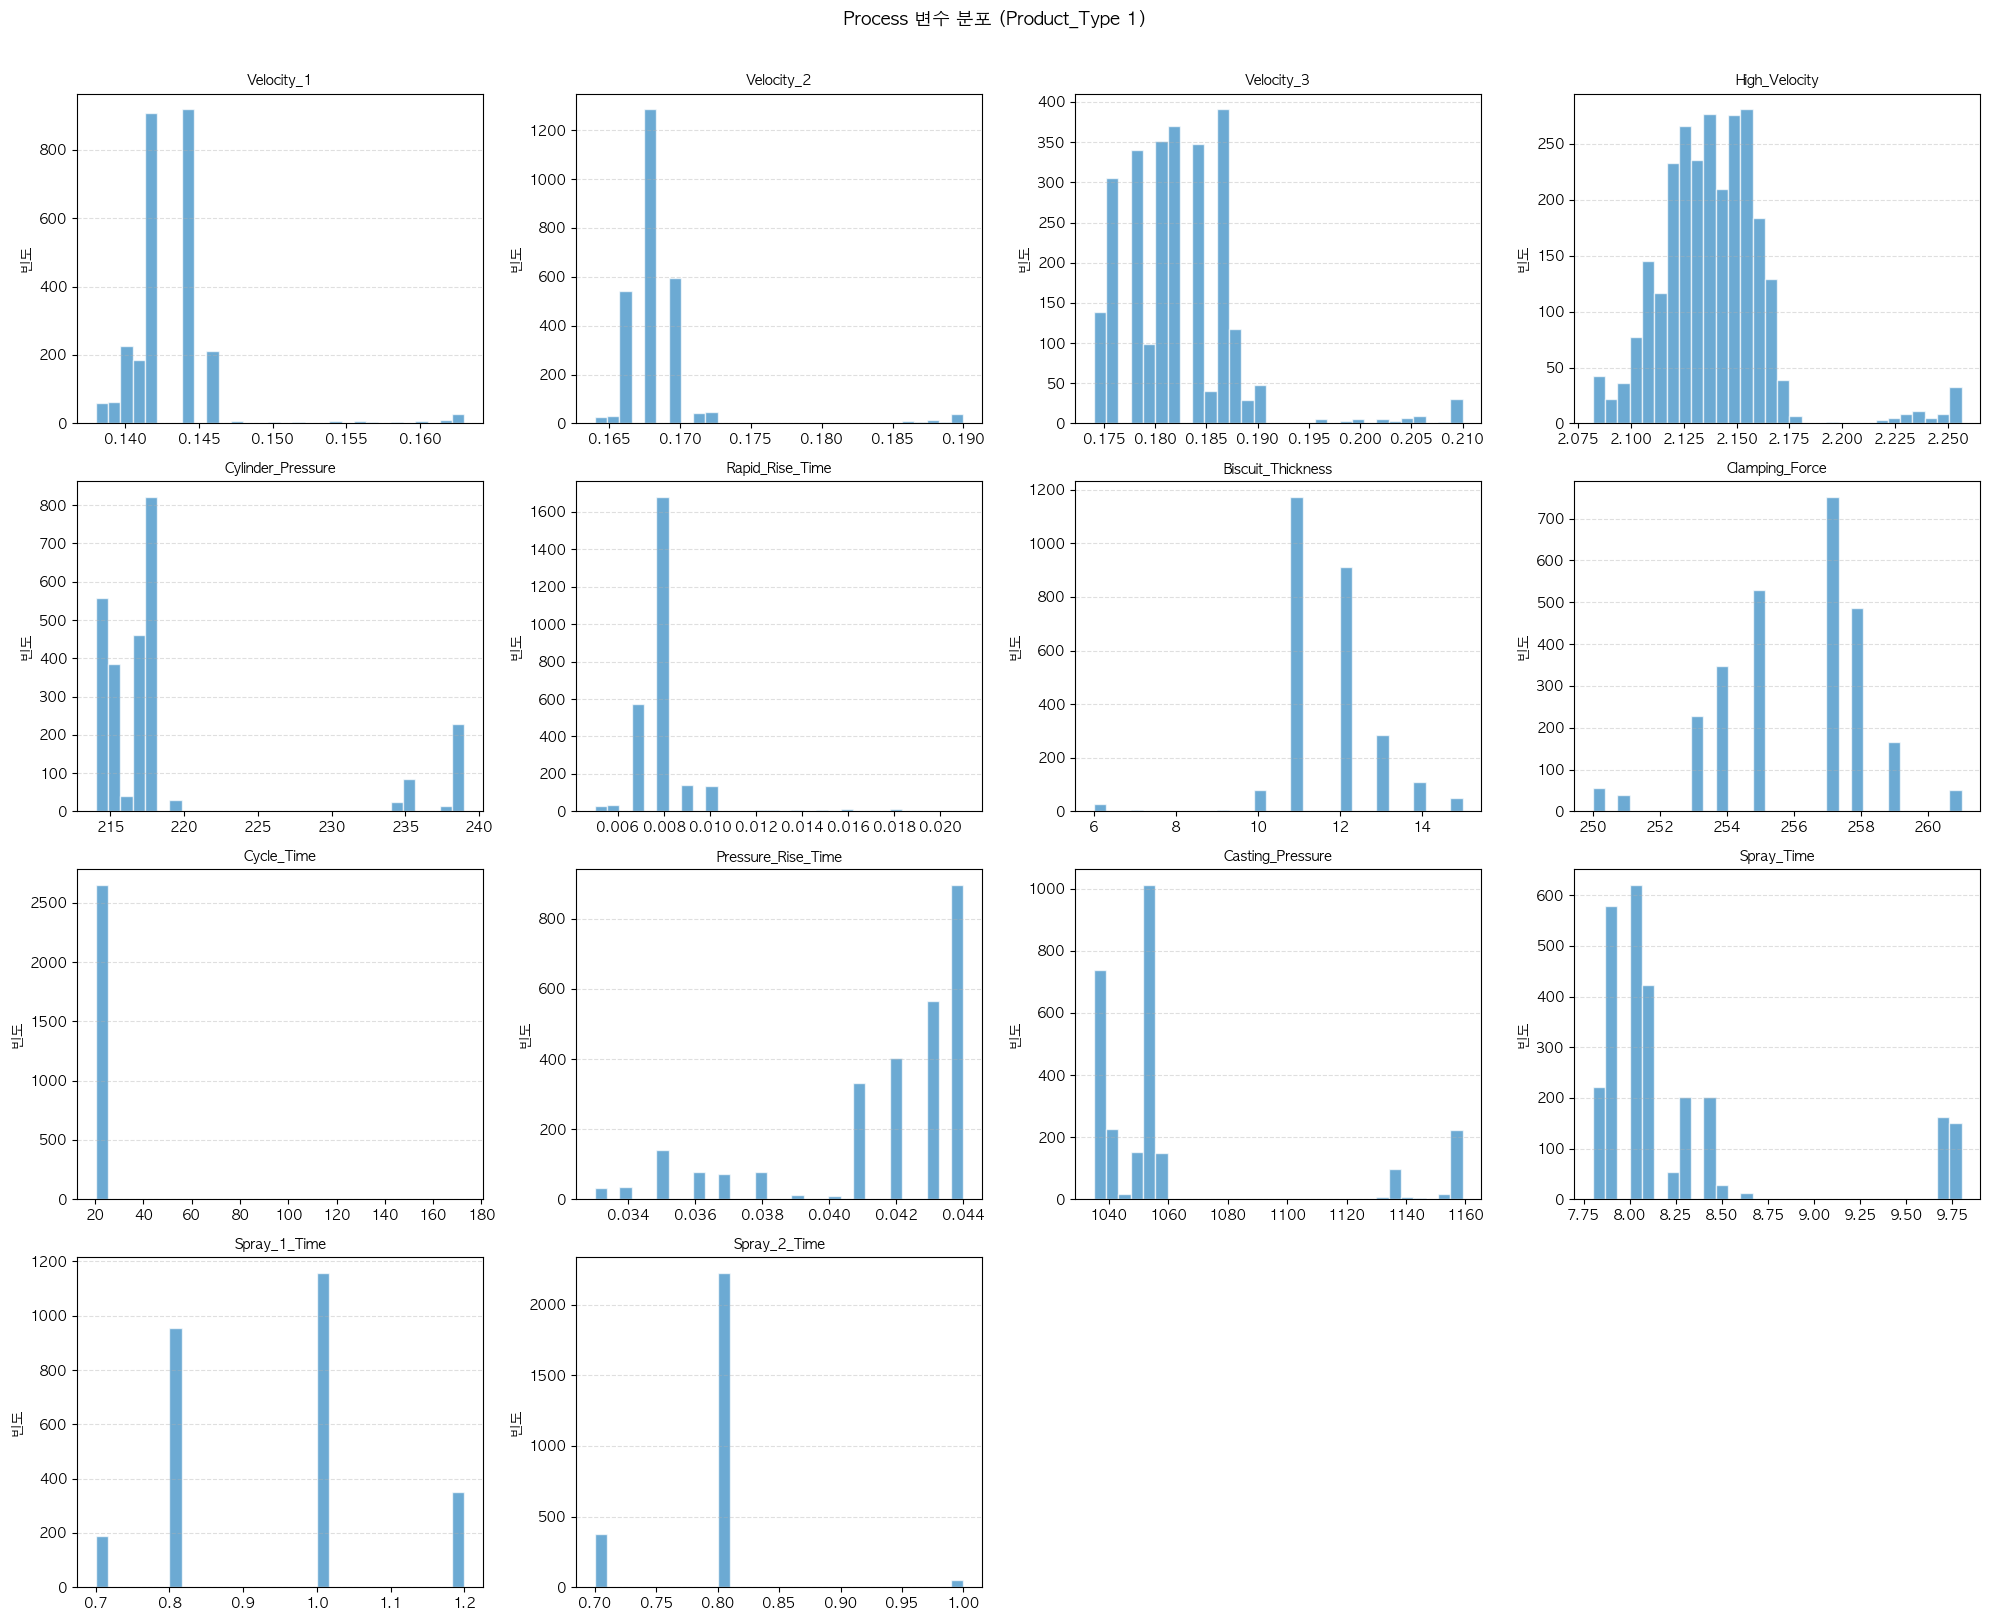

In [14]:
# Process 변수 히스토그램 + 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

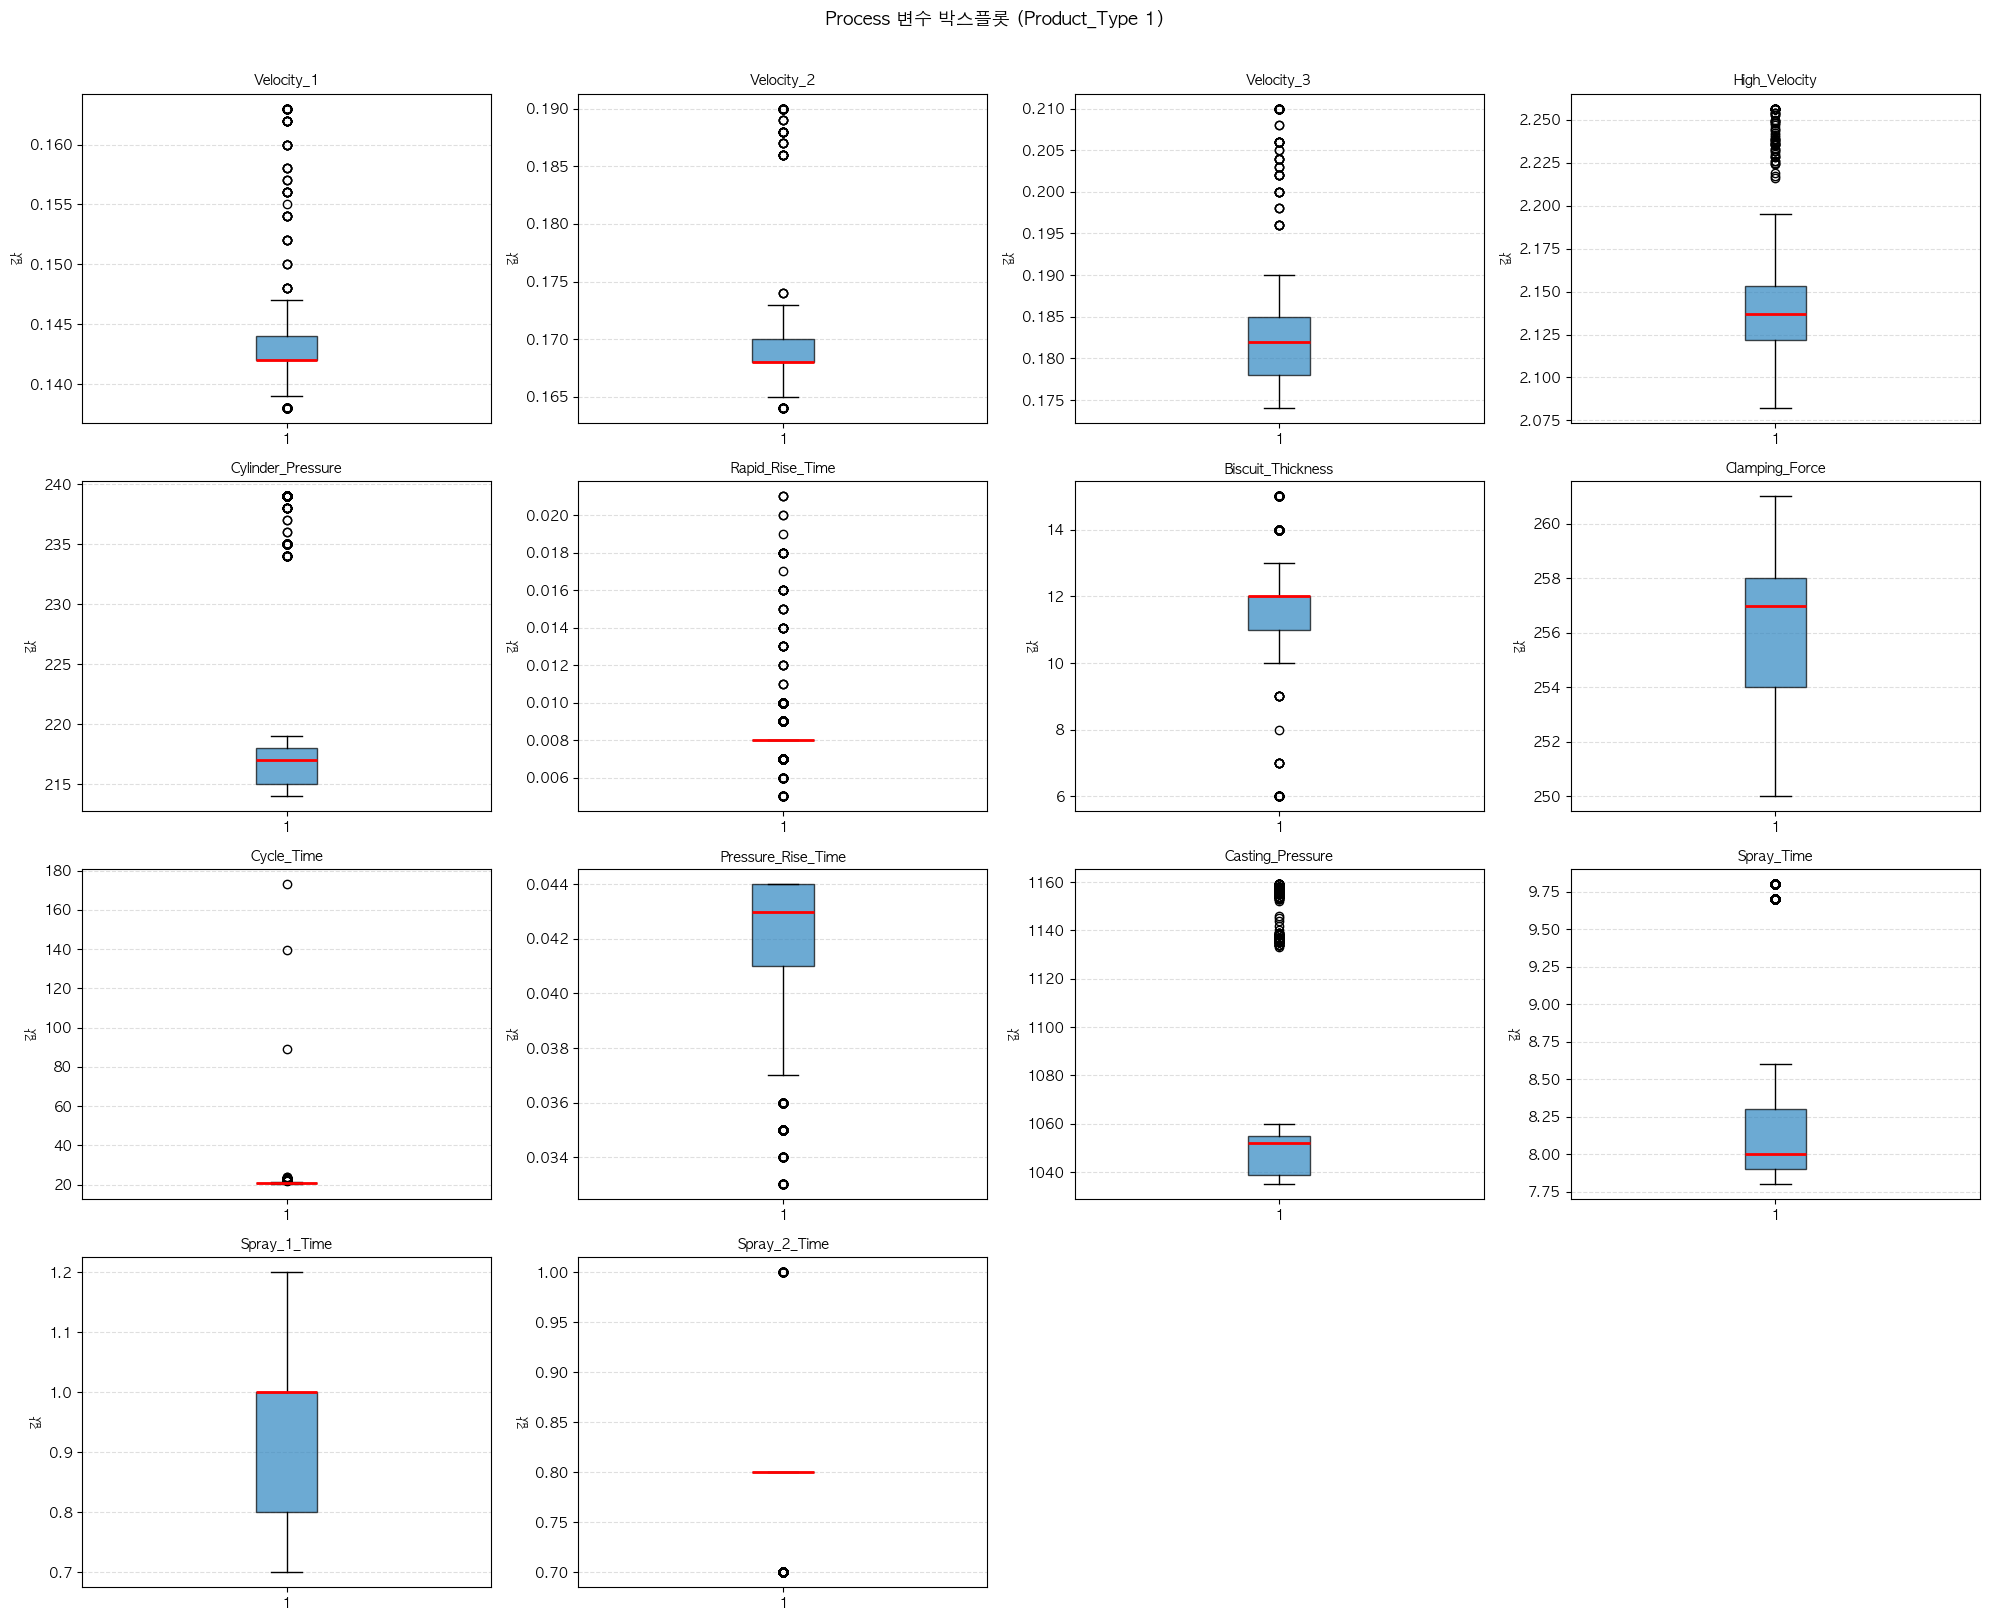

In [15]:
# Process 변수 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('값')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 박스플롯 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

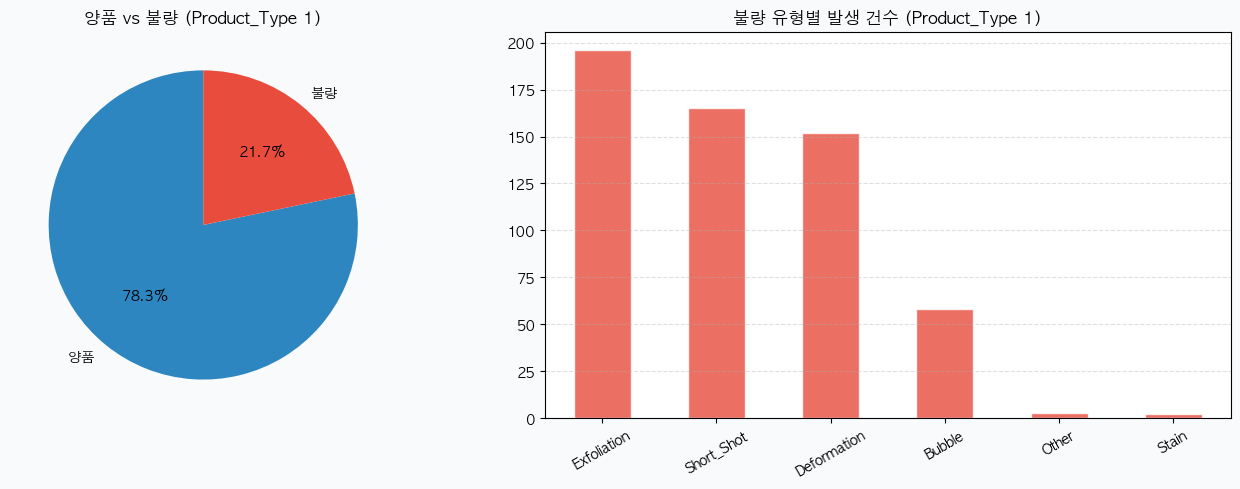

In [16]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = df['Defect_Status'].value_counts()
axes[0].pie(sizes, labels=['양품','불량'], autopct='%1.1f%%',
            colors=['#2E86C1','#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = df[df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## STEP 8. 전처리 완료 데이터 저장

In [17]:
save_cols = (
    ['id','Product_Type','Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp',
       'Coolant_Pressure','Factory_Temp','Factory_Humidity']
    + ['Defect_Status','Defect_Type']
)
df_clean = df[save_cols].copy()
df_clean.to_csv('DieCasting_Preprocessed_Type1.csv', index=False)

print(f"✅ 저장 완료: DieCasting_Preprocessed_Type1.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
df_clean.head(3)

✅ 저장 완료: DieCasting_Preprocessed_Type1.csv
   최종 Shape: 2651행 × 25열


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Defect_Status,Defect_Type
0,1,1,1,0.144,0.17,0.188,2.134,214,0.008,10,...,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,Normal
1,1002,1,2,0.144,0.17,0.182,2.124,217,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
2,2003,1,3,0.144,0.17,0.182,2.116,214,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
